# 04 — XGBoost (weekly silver volatility)

XGBoost on the **same three HAR own-history features** used by OLS-HAR and the
Random Forest headline model. This makes the early comparison a clean estimator test:
linear HAR versus nonlinear boosting on the same volatility-memory inputs. Cross-asset
EXOG spillovers are tested later in the ablation ladder.

Hyperparameters are tuned on the validation split, then the model is re-fit on
train+val. Features come from `volatility_weekly.csv` — run `00_features.ipynb` first.


## Setup


In [1]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
from vol_utils import vol_evaluate, vol_period_metrics, vol_diebold_mariano, walk_forward
from eval_utils import PERIODS
import warnings; warnings.filterwarnings('ignore')

SEED = 42
plt.rcParams['figure.figsize'] = (10, 4)

frame = pd.read_csv('../../data/processed/volatility_weekly.csv',
                    parse_dates=['Date']).set_index('Date')
train_df = frame[frame['split'] == 'train']
val_df   = frame[frame['split'] == 'val']
test_df  = frame[frame['split'] == 'test']
trval_df = frame[frame['split'] != 'test']

FEATS_AR1  = ['rv_w_lag1']
FEATS_HAR  = ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
print('headline features:', FEATS_HAR)

headline features: ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']


## 1. Hyperparameter tuning

Small grid search over tree count / depth / learning rate. Each configuration is fit on
the train split and scored by RMSE on the validation split; the lowest-RMSE
configuration is kept.


In [2]:
y_tr = train_df['target']; y_v = val_df['target']

def tune_xgb(X_tr, y_tr, X_v, y_v):
    grid = ParameterGrid({'n_estimators': [200, 400], 'max_depth': [3, 5],
                          'learning_rate': [0.03, 0.1]})
    best = (np.inf, None)
    for p in grid:
        m = XGBRegressor(random_state=SEED, verbosity=0, **p).fit(X_tr, y_tr)
        rmse = np.sqrt(mean_squared_error(y_v, m.predict(X_v)))
        if rmse < best[0]:
            best = (rmse, p)
    return best[1]

xgb_best = tune_xgb(train_df[FEATS_HAR], y_tr, val_df[FEATS_HAR], y_v)
print('XGB best params:', xgb_best)


XGB best params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200}


## 2. Refit on train+val and evaluate

The best configuration is re-fit on train+val combined, then scored once on the test
set.


In [3]:
y_test    = test_df['target'].values
prev_test = test_df['rv_w_lag1'].values

# Single-fit on train+val with the tuned hyperparameters; keeps a canonical `xgb`
# model around for §4 feature-importance interpretation (gain importance).
xgb = XGBRegressor(random_state=SEED, verbosity=0, importance_type='gain',
                   **xgb_best).fit(trval_df[FEATS_HAR], trval_df['target'])
xgb_pred_single = xgb.predict(test_df[FEATS_HAR])

# Walk-forward XGB: refit every 4 weeks on all data up to t-1 (expanding window),
# frozen hyperparameters from §1.
def _xgb_fit(X, y, params=xgb_best):
    return XGBRegressor(random_state=SEED, verbosity=0, **params).fit(X, y)

xgb_pred = walk_forward(frame, test_df.index, FEATS_HAR, fit_fn=_xgb_fit, refit_every=4)

results = [vol_evaluate('XGB (HAR)', y_test, xgb_pred, prev_test)]

# Single-fit RMSE for reference.
print(f'\nSingle-fit XGB (HAR) RMSE (for reference): '
      f'{np.sqrt(((y_test - xgb_pred_single)**2).mean()):.5f}    '
      f'walk-forward RMSE: {np.sqrt(((y_test - xgb_pred)**2).mean()):.5f}')

XGB (HAR)                       RMSE=0.03133  MAE=0.01765  R2=+0.324  DCA=0.690

Single-fit XGB (HAR) RMSE (for reference): 0.03630    walk-forward RMSE: 0.03133


## 3. DM vs the Naïve floor — does XGB beat $\text{RV}_{t-1}$?

The chapter's central question, restated for the gradient-boosted model: is weekly
silver volatility predictable beyond last week's value? Diebold-Mariano (1995) with
Newey-West (1987) lag-1 variance via `vol_diebold_mariano`; negative DM = XGB has lower
loss.

**QLIKE is the primary loss.** Weekly silver RV is heavy-tailed enough that under
squared-error loss a handful of extreme weeks dominate the differential and inflate the
DM variance, so an RMSE improvement that is real and steady can still fail an MSE-DM
test. The volatility-forecasting literature (Patton 2011) reports forecasts under
**QLIKE**, a proxy-robust ratio loss; squared-error DM is kept underneath only as a
reference. The same comparison is collected across models in `evaluation.ipynb` §4.


In [4]:
# Diebold-Mariano: XGB (HAR) vs the Naive RV_{t-1} floor.
print('QLIKE loss  --  primary test:')
vol_diebold_mariano(y_test, xgb_pred, prev_test, 'XGB (HAR)', 'Naive', loss='qlike')

print('\nSquared-error loss  --  reference:')
vol_diebold_mariano(y_test, xgb_pred, prev_test, 'XGB (HAR)', 'Naive', loss='mse');


QLIKE loss  --  primary test:
XGB (HAR)                    vs Naive         [qlike]  DM=-2.625  p=0.009  **    -> winner: XGB (HAR)

Squared-error loss  --  reference:
XGB (HAR)                    vs Naive         [mse  ]  DM=-1.089  p=0.276  (ns)  -> winner: tie


## 4. Sub-period breakdown

RMSE and DCA split by calendar year, using the shared `PERIODS` definition.


In [5]:
period_xgb = vol_period_metrics(y_test, xgb_pred, prev_test, test_df.index, PERIODS)
period_xgb.to_csv('../../data/processed/period_xgb_volatility.csv')
period_xgb.round(4)


,n,RMSE,MAE,DCA
Period,,,,
2023 (choppy),52,0.0150,0.0123,0.6923
2024 (bull start),52,0.0163,0.0131,0.7308
2025 (bull run),52,0.0241,0.0175,0.6346
2026 (YTD),18,0.0799,0.0466,0.7222
── Full test ──,174,0.0313,0.0176,0.6897


## 5. Ablations

Same ablation ladder as the HAR-RV ablation in `02_har` §5 and the Random Forest
ablation in `03_random_forest` §5, with XGBoost as the model. Running the same rungs
in three model classes (OLS, RF, XGB) makes the linear-vs-nonlinear contribution
comparable rung-by-rung.

| Rung | Tests |
|---|---|
| `XGB (AR1)` | XGB on last week's RV only — nonlinear AR(1) sanity check |
| `XGB (HAR)` | XGB on the three HAR features — fair nonlinear comparison to OLS-HAR |
| `XGB (HAR+EXOG)` | full cross-asset spillover |
| `XGB (HAR+RedditAttention)` | Reddit attention |
| `XGB (HAR+RedditSent)` | Reddit tone intensity (\|tone\|) |
| `XGB (HAR+Reddit)` | Reddit combined |
| `XGB (HAR+Trends)` | Google-search retail attention |
| `XGB (HAR+PaidAttention)` | paid-news volume |
| `XGB (HAR+PaidSent)` | paid-news tone intensity |
| `XGB (HAR+Paid)` | paid-news combined |

Every rung is hyperparameter-tuned independently (`tune_xgb` on the sentiment-available
training subsample) and re-fit on train+val of that subsample, so every rung sees the
same observations and the DM comparison is apples-to-apples. **Primary** QLIKE-DM is
each rung vs the bare `XGB (HAR)` baseline; the **secondary** test pits the combined
Reddit rung against `XGB (HAR+EXOG)`.

In [6]:
FEATS_SENT_ATTN = ['reddit_attention_lag1']
FEATS_SENT_INT  = ['reddit_sent_abs_lag1',
                #    'reddit_sent_disp_lag1'   # dropped per 00_features §2.5 EDA -- mirrors 02_har §5
                   ]
FEATS_SENT      = FEATS_SENT_ATTN + FEATS_SENT_INT
FEATS_TRENDS    = ['trends_lag1']  # Google-search attention (§5)
FEATS_PAID_ATTN = ['paid_attention_lag1']
FEATS_PAID_INT  = ['paid_sent_abs_lag1']   # paid_sent_disp_lag1 built in 00_features; pending EDA

FEATS_EXOG     = [c for c in frame.columns
                   if c.endswith('_rv_lag1') and not c.startswith('silver')]
FEATS_ALL      = FEATS_HAR + FEATS_EXOG

# True-mirror ablation ladder of 02_har §5: sentiment rungs add to bare HAR (no EXOG).
LADDER = {
    'XGB (AR1)':                  FEATS_AR1,
    'XGB (HAR)':                  FEATS_HAR,
    'XGB (HAR+EXOG)':             FEATS_HAR + FEATS_EXOG,
    'XGB (HAR+RedditAttention)':  FEATS_HAR + FEATS_SENT_ATTN,
    'XGB (HAR+RedditSent)':       FEATS_HAR + FEATS_SENT_INT,
    'XGB (HAR+Reddit)':           FEATS_HAR + FEATS_SENT_ATTN + FEATS_SENT_INT,
    'XGB (HAR+Trends)':           FEATS_HAR + FEATS_TRENDS,
    'XGB (HAR+PaidAttention)':    FEATS_HAR + FEATS_PAID_ATTN,
    'XGB (HAR+PaidSent)':         FEATS_HAR + FEATS_PAID_INT,
    'XGB (HAR+Paid)':             FEATS_HAR + FEATS_PAID_ATTN + FEATS_PAID_INT,
}

# Common sample: every rung fitted/scored on weeks where all features exist
all_sent_cols = FEATS_SENT + FEATS_TRENDS + FEATS_PAID_ATTN + FEATS_PAID_INT
abl         = frame.dropna(subset=all_sent_cols)
sent_train  = train_df.dropna(subset=all_sent_cols)
sent_test   = abl[abl['split'] == 'test']
y_st, prev_st = sent_test['target'].values, sent_test['rv_w_lag1'].values
print(f'ablation sample: train+val={(abl["split"]!="test").sum()}  test={len(sent_test)}\n')

# Tune hyperparams once per rung (frozen across walk-forward refits) and walk forward
# refitting every 4 weeks.
abl_pred, abl_results = {}, []
for name, feats in LADDER.items():
    best = tune_xgb(sent_train[feats], sent_train['target'],
                    val_df[feats],     val_df['target'])
    def _fit(X, y, _b=best):
        return XGBRegressor(random_state=SEED, verbosity=0, **_b).fit(X, y)
    pred = walk_forward(abl, sent_test.index, feats, fit_fn=_fit, refit_every=4)
    abl_pred[name] = pred
    abl_results.append(vol_evaluate(name, y_st, pred, prev_st))

# Primary QLIKE-DM: each rung vs the bare XGB (HAR) baseline -- mirrors 02_har §5
print()
dm = {}
for name in LADDER:
    if name == 'XGB (HAR)':
        continue
    dm[name] = vol_diebold_mariano(y_st, abl_pred[name], abl_pred['XGB (HAR)'],
                                   name, 'XGB (HAR)', loss='qlike')

# Secondary: does the combined Reddit rung beat XGB (HAR+EXOG)?
# Mirrors HAR+Reddit vs HAR+EXOG in 02_har §5.
print()
vol_diebold_mariano(y_st, abl_pred['XGB (HAR+Reddit)'],
                          abl_pred['XGB (HAR+EXOG)'],
                          'XGB+Reddit', 'XGB+EXOG', loss='qlike')

# Squared-error DM -- reference (mirrors §3; QLIKE is primary)
print('\nSquared-error loss  --  reference:')
dm_mse = {}
for name in LADDER:
    if name == 'XGB (HAR)':
        continue
    dm_mse[name] = vol_diebold_mariano(y_st, abl_pred[name], abl_pred['XGB (HAR)'],
                                       name, 'XGB (HAR)', loss='mse')

print()
vol_diebold_mariano(y_st, abl_pred['XGB (HAR+Reddit)'],
                          abl_pred['XGB (HAR+EXOG)'],
                          'XGB+Reddit', 'XGB+EXOG', loss='mse')

abl_df = pd.DataFrame(abl_results)
abl_df['dm_qlike']   = abl_df['model'].map(lambda m: dm[m]['dm']     if m in dm     else np.nan)
abl_df['dm_qlike_p'] = abl_df['model'].map(lambda m: dm[m]['p']      if m in dm     else np.nan)
abl_df['dm_mse']     = abl_df['model'].map(lambda m: dm_mse[m]['dm'] if m in dm_mse else np.nan)
abl_df['dm_mse_p']   = abl_df['model'].map(lambda m: dm_mse[m]['p']  if m in dm_mse else np.nan)
abl_df['winner_dm_qlike'] = abl_df['model'].map(lambda m: dm[m]['winner']     if m in dm     else np.nan)
abl_df['winner_dm_mse']   = abl_df['model'].map(lambda m: dm_mse[m]['winner'] if m in dm_mse else np.nan)

abl_pred_df = pd.DataFrame({'actual': y_abl if 'y_abl' in globals() else y_st,
                            'naive': prev_abl if 'prev_abl' in globals() else prev_st},
                           index=abl_test.index if 'abl_test' in globals() else sent_test.index)
for _name, _pred in abl_pred.items():
    abl_pred_df[_name] = _pred
abl_pred_df.to_csv('../../data/processed/pred_xgb_sentiment_volatility.csv', index_label='Date')
abl_df.to_csv('../../data/processed/metrics_xgb_sentiment_volatility.csv', index=False)
print('\nSaved metrics_xgb_sentiment_volatility.csv')
abl_df.round(5)

ablation sample: train+val=402  test=174



XGB (AR1)                       RMSE=0.03429  MAE=0.01829  R2=+0.190  DCA=0.632


XGB (HAR)                       RMSE=0.03329  MAE=0.01900  R2=+0.237  DCA=0.661


XGB (HAR+EXOG)                  RMSE=0.03419  MAE=0.01756  R2=+0.195  DCA=0.684


XGB (HAR+RedditAttention)       RMSE=0.03099  MAE=0.01737  R2=+0.339  DCA=0.684


...

XGB (HAR+Trends)                RMSE=0.03255  MAE=0.01793  R2=+0.270  DCA=0.667


XGB (HAR+PaidAttention)         RMSE=0.03205  MAE=0.01752  R2=+0.292  DCA=0.695


XGB (HAR+PaidSent)              RMSE=0.03090  MAE=0.01731  R2=+0.342  DCA=0.678


XGB (HAR+Paid)                  RMSE=0.03210  MAE=0.01815  R2=+0.290  DCA=0.684

XGB (AR1)                    vs XGB (HAR)     [qlike]  DM=+0.248  p=0.804  (ns)  -> winner: tie
XGB (HAR+EXOG)               vs XGB (HAR)     [qlike]  DM=+0.601  p=0.548  (ns)  -> winner: tie
XGB (HAR+RedditAttention)    vs XGB (HAR)     [qlike]  DM=-2.359  p=0.018  *     -> winner: XGB (HAR+RedditAttention)
XGB (HAR+RedditSent)         vs XGB (HAR)     [qlike]  DM=-2.439  p=0.015  *     -> winner: XGB (HAR+RedditSent)
XGB (HAR+Reddit)             vs XGB (HAR)     [qlike]  DM=-0.738  p=0.461  (ns)  -> winner: tie
XGB (HAR+Trends)             vs XGB (HAR)     [qlike]  DM=-1.830  p=0.067  (ns)  -> winner: tie
XGB (HAR+PaidAttention)      vs XGB (HAR)     [qlike]  DM=-2.197  p=0.028  *     -> winner: XGB (HAR+PaidAttention)
XGB (HAR+PaidSent)           vs XGB (HAR)     [qlike]  DM=-2.293  p=0.022  *     -> winner: XGB (HAR+PaidSent)
XGB (HAR+Paid)               vs XGB (HAR)     [qlike]  DM=-1.682  p=0.093  (n

,model,rmse,mae,r2,dca,dm_qlike,dm_qlike_p,dm_mse,dm_mse_p,winner_dm_qlike,winner_dm_mse
0,XGB (AR1),0.03429,0.01829,0.19043,0.63218,0.24789,0.80422,0.64023,0.52203,tie,tie
1,XGB (HAR),0.03329,0.01900,0.23675,0.66092,NaN,NaN,NaN,NaN,NaN,NaN
2,XGB (HAR+EXOG),0.03419,0.01756,0.19521,0.68391,0.60096,0.54787,0.45832,0.64672,tie,tie
3,XGB (HAR+RedditAttention),0.03099,0.01737,0.33877,0.68391,-2.35879,0.01833,-2.06973,0.03848,XGB (HAR+RedditAttention),XGB (HAR+RedditAttention)
4,XGB (HAR+RedditSent),0.03194,0.01732,0.29765,0.70690,-2.43946,0.01471,-1.82620,0.06782,XGB (HAR+RedditSent),tie
5,XGB (HAR+Reddit),0.03170,0.01747,0.30811,0.70690,-0.73756,0.46078,-1.29319,0.19594,tie,tie
6,XGB (HAR+Trends),0.03255,0.01793,0.27016,0.66667,-1.82953,0.06732,-0.75898,0.44787,tie,tie
7,XGB (HAR+PaidAttention),0.03205,0.01752,0.29241,0.69540,-2.19692,0.02803,-1.87545,0.06073,XGB (HAR+PaidAttention),tie
8,XGB (HAR+PaidSent),0.03090,0.01731,0.34234,0.67816,-2.29276,0.02186,-1.52594,0.12703,XGB (HAR+PaidSent),tie
9,XGB (HAR+Paid),0.03210,0.01815,0.29037,0.68391,-1.68166,0.09264,-1.20095,0.22977,tie,tie


## 6. Permutation importance — OOS view of the combined sentiment rung

**Permutation importance** (Breiman 2001; sklearn's `permutation_importance`): shuffle each feature in the test set and measure how much the test MSE worsens. A feature with high permutation importance genuinely drives OOS predictions; permutation importance ≈ 0 means the feature contributes nothing out-of-sample even if gain gives it a non-zero score.

Computed for `XGB (HAR+EXOG+Trends+Reddit+Paid)` so all features appear in both panels. The left panel shows **gain** (in-sample loss reduction across all boosting splits); the right shows **permutation importance** on the test set. Features where the two diverge are split-on in-sample but don't help OOS.

Asier: understand the permutation importance and the different types of feature importance.

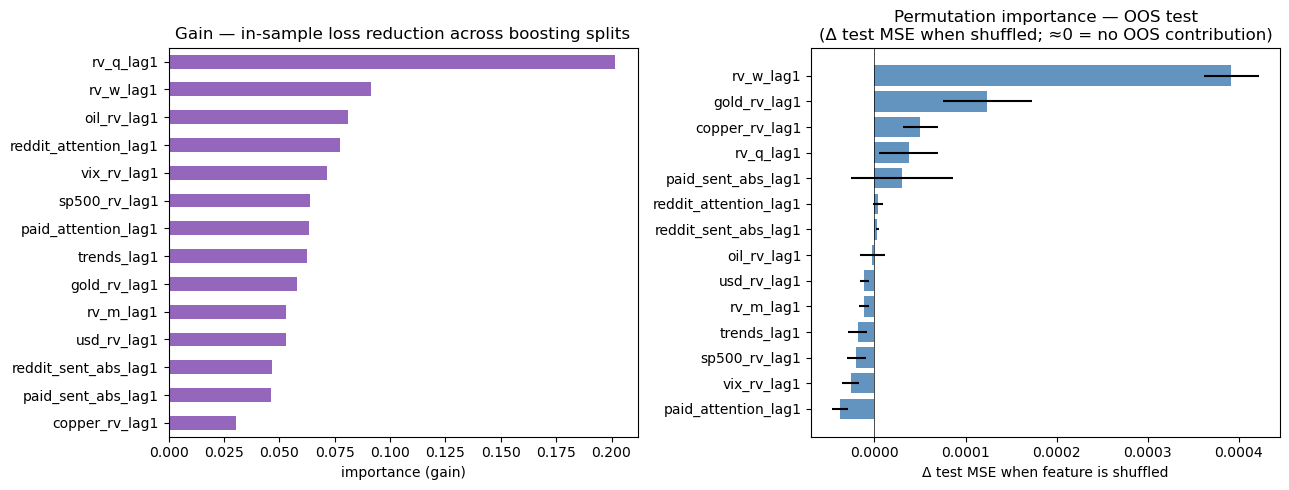

Gain (in-sample) ranking:
rv_q_lag1                0.2016
rv_w_lag1                0.0915
oil_rv_lag1              0.0810
reddit_attention_lag1    0.0772
vix_rv_lag1              0.0714
sp500_rv_lag1            0.0640
paid_attention_lag1      0.0633
trends_lag1              0.0624
gold_rv_lag1             0.0580
rv_m_lag1                0.0531
usd_rv_lag1              0.0528
reddit_sent_abs_lag1     0.0469
paid_sent_abs_lag1       0.0462
copper_rv_lag1           0.0305

Permutation importance (OOS test) ranking:
rv_w_lag1                0.000392
gold_rv_lag1             0.000124
copper_rv_lag1           0.000050
rv_q_lag1                0.000037
paid_sent_abs_lag1       0.000030
reddit_attention_lag1    0.000004
reddit_sent_abs_lag1     0.000003
oil_rv_lag1             -0.000002
usd_rv_lag1             -0.000011
rv_m_lag1               -0.000011
trends_lag1             -0.000019
sp500_rv_lag1           -0.000020
vix_rv_lag1             -0.000026
paid_attention_lag1     -0.000038


In [7]:
from sklearn.inspection import permutation_importance

# Re-fit the combined sentiment rung (HAR + EXOG + Reddit + paid-news) canonically on
# sent_trval (single fit on train+val) and compute two importance measures side-by-side
# on the test set:
#   (a) Gain -- in-sample loss-reduction across all the boosting splits.
#   (b) Permutation importance (Breiman 2001) -- shuffles each test-set feature
#       and measures the rise in test MSE; perm-importance ≈ 0 means the feature
#       contributes nothing to OOS predictions even if gain gives it a non-zero
#       score.
# The contrast is the diagnostic for whether sentiment is genuinely used OOS or
# just split-on in-sample.
combined_feats = FEATS_HAR + FEATS_EXOG + FEATS_SENT_ATTN + FEATS_SENT_INT + FEATS_TRENDS + FEATS_PAID_ATTN + FEATS_PAID_INT
sent_trval     = abl[abl['split'] != 'test']

combined_best = tune_xgb(sent_train[combined_feats], sent_train['target'],
                         val_df[combined_feats],     val_df['target'])
model = XGBRegressor(random_state=SEED, verbosity=0, importance_type='gain',
                     **combined_best).fit(sent_trval[combined_feats], sent_trval['target'])

gain = pd.Series(model.feature_importances_, index=combined_feats)
perm = permutation_importance(model, sent_test[combined_feats], y_st,
                              n_repeats=20, random_state=SEED,
                              scoring='neg_mean_squared_error')
perm_mean = pd.Series(perm.importances_mean, index=combined_feats)
perm_std  = pd.Series(perm.importances_std,  index=combined_feats)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
gain.sort_values().plot.barh(ax=ax[0], color='#9467bd')
ax[0].set_title('Gain — in-sample loss reduction across boosting splits')
ax[0].set_xlabel('importance (gain)')

ord_perm = perm_mean.sort_values().index
ax[1].barh(ord_perm, perm_mean[ord_perm], xerr=perm_std[ord_perm],
           color='steelblue', alpha=0.85)
ax[1].axvline(0, color='black', lw=0.5)
ax[1].set_title('Permutation importance — OOS test\n(Δ test MSE when shuffled; ≈0 = no OOS contribution)')
ax[1].set_xlabel('Δ test MSE when feature is shuffled')

plt.tight_layout(); plt.show()

print('Gain (in-sample) ranking:')
print(gain.sort_values(ascending=False).round(4).to_string())
print('\nPermutation importance (OOS test) ranking:')
print(perm_mean.sort_values(ascending=False).round(6).to_string())

## 7. Save outputs

- `metrics_xgb_volatility.csv` — XGBoost headline metrics
- `pred_xgb_volatility.csv` — test-set predictions, consumed by `evaluation.ipynb`
- `metrics_xgb_sentiment_volatility.csv` — the §5 sentiment-ablation table (saved above)

In [8]:
pd.DataFrame(results).to_csv('../../data/processed/metrics_xgb_volatility.csv', index=False)

pred_xgb = pd.DataFrame({'actual': y_test, 'prev': prev_test, 'xgb': xgb_pred}, index=test_df.index)
pred_xgb.to_csv('../../data/processed/pred_xgb_volatility.csv', index_label='Date')
print('Saved metrics_xgb_volatility.csv + pred_xgb_volatility.csv')
pd.DataFrame(results).round(5)


Saved metrics_xgb_volatility.csv + pred_xgb_volatility.csv


,model,rmse,mae,r2,dca
0,XGB (HAR),0.03133,0.01765,0.32392,0.68966
